## Environment Setup

In [1]:
!pip install -q earthengine-api scikit-image scikit-learn pandas numpy matplotlib

## Dataset Loader

In [2]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
import random

class ForestAnomalyDataset(Dataset):
    def __init__(self, folder_path):
        self.file_list = glob.glob(os.path.join(folder_path, "*.npy"))
        
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        data = np.load(self.file_list[idx]).astype(np.float32)
        
        # Min-Max Normalization (Raw Sentinel-2 to [0, 1])
        data = np.clip(data / 10000.0, 0, 1)
        
        # Convert to Tensor (C, H, W)
        x = torch.from_numpy(data).permute(2, 0, 1)
        
        # Data Augmentation
        # Random Horizontal/Vertical Flips
        if random.random() > 0.5: x = T.functional.hflip(x)
        if random.random() > 0.5: x = T.functional.vflip(x)
        
        return x

# Updated Dataset Loader Cell
train_dataset = ForestAnomalyDataset('/kaggle/input/datasets/sefyou13/clean-forest-dataset-fire-forest-modis/dataset/train')
val_clean_dataset = ForestAnomalyDataset('/kaggle/input/datasets/sefyou13/clean-forest-dataset-fire-forest-modis/dataset/val_clean')
fire_test_dataset = ForestAnomalyDataset('/kaggle/input/datasets/sefyou13/clean-forest-dataset-fire-forest-modis/dataset/test_fire')

# We use shuffle=True only for training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# Shuffle=False for validation and testing to keep results consistent
val_loader = DataLoader(val_clean_dataset, batch_size=32, shuffle=False)
fire_loader = DataLoader(fire_test_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} patches")
print(f"Val (Clean): {len(val_clean_dataset)} patches")
print(f"Test (Fire): {len(fire_test_dataset)} patches")

Train: 1116 patches
Val (Clean): 279 patches
Test (Fire): 565 patches


## VAE-WGAN Architecture

In [3]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(Encoder, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)

    def forward(self, x):
        h = self.main(x)
        return self.fc_mu(h), self.fc_logvar(h)

class Generator(nn.Module):
    def __init__(self, latent_dim=128):
        super(Generator, self).__init__()
        self.fc = nn.Linear(latent_dim, 256 * 8 * 8)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 4, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 8, 8)
        return self.main(h)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 1) # Output for WGAN is a score, not a sigmoid probability
        )

    def forward(self, x):
        return self.main(x)

## Gradient Penalty Function

In [4]:
import torch.autograd as autograd

def compute_gradient_penalty(D, real_samples, fake_samples, device):
    """Calculates the gradient penalty loss for WGAN GP"""
    # Random weight term for interpolation between real and fake samples
    alpha = torch.rand((real_samples.size(0), 1, 1, 1)).to(device)
    
    # Get random interpolation between real and fake samples
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    
    d_interpolates = D(interpolates)
    fake = torch.ones(d_interpolates.shape).to(device)
    
    # Get gradient w.r.t. interpolates
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

## Training Logic (The WGAN)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128

enc = Encoder(latent_dim).to(device)
gen = Generator(latent_dim).to(device)
dis = Discriminator().to(device)

opt_encgen = optim.Adam(list(enc.parameters()) + list(gen.parameters()), lr=0.0002)
opt_dis = optim.Adam(dis.parameters(), lr=0.0001)

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# Simplified Training Loop
epochs = 30
for epoch in range(epochs):
    for i, x in enumerate(train_loader):
        x = x.to(device)

        # Train Discriminator
        opt_dis.zero_grad()
        mu, logvar = enc(x)
        z = reparameterize(mu, logvar)
        x_recon = gen(z)
        
        # WGAN-GP Discriminator Loss
        lambda_gp = 10  # Standard value recommended by the WGAN-GP paper
        gradient_penalty = compute_gradient_penalty(dis, x.data, x_recon.data, device)
        
        loss_dis = -torch.mean(dis(x)) + torch.mean(dis(x_recon.detach())) + lambda_gp * gradient_penalty
        loss_dis.backward()
        opt_dis.step()

        # Train Encoder/Decoder
        opt_encgen.zero_grad()
        x_recon = gen(z)
        recon_loss = nn.MSELoss()(x_recon, x)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        gen_loss = -torch.mean(dis(x_recon))
        
        total_loss = recon_loss + 0.01 * kl_loss + 0.1 * gen_loss
        total_loss.backward()
        opt_encgen.step()
    
    print(f"Epoch [{epoch}/{epochs}] Loss: {total_loss.item():.4f}")

# Save the final models
torch.save(enc.state_dict(), 'encoder_final.pth')
torch.save(gen.state_dict(), 'generator_final.pth')
torch.save(dis.state_dict(), 'discriminator_final.pth')
print("Models saved successfully")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [0/30] Loss: 1.7365
Epoch [1/30] Loss: 1.7942
Epoch [2/30] Loss: 2.1390
Epoch [3/30] Loss: 2.1453
Epoch [4/30] Loss: 2.1897
Epoch [5/30] Loss: 1.2787
Epoch [6/30] Loss: 0.4384
Epoch [7/30] Loss: 0.3245
Epoch [8/30] Loss: 0.2134
Epoch [9/30] Loss: 0.1834
Epoch [10/30] Loss: 0.1009
Epoch [11/30] Loss: 0.0968
Epoch [12/30] Loss: 0.1215
Epoch [13/30] Loss: 0.0628
Epoch [14/30] Loss: 0.1192
Epoch [15/30] Loss: 0.1404
Epoch [16/30] Loss: 0.1622
Epoch [17/30] Loss: 0.1091
Epoch [18/30] Loss: 0.1374
Epoch [19/30] Loss: 0.0878
Epoch [20/30] Loss: 0.1662
Epoch [21/30] Loss: 0.0613
Epoch [22/30] Loss: 0.1091
Epoch [23/30] Loss: 0.1608
Epoch [24/30] Loss: 0.2295
Epoch [25/30] Loss: 0.1068
Epoch [26/30] Loss: 0.2187
Epoch [27/30] Loss: 0.1190
Epoch [28/30] Loss: 0.0906
Epoch [29/30] Loss: 0.0314
Models saved successfully


## Evaluation (ROC Curve & Thresholding)

Calculating metrics for Val (Clean) and Test (Fire)...

FINAL METRICS
ROC-AUC: 0.9505
PR-AUC:  0.9728
Average SSIM (Clean): 0.5624
Average SSIM (Fire):  0.2741
SSIM (Clean - Fire):      0.2884
Optimal MSE Threshold: 0.002207


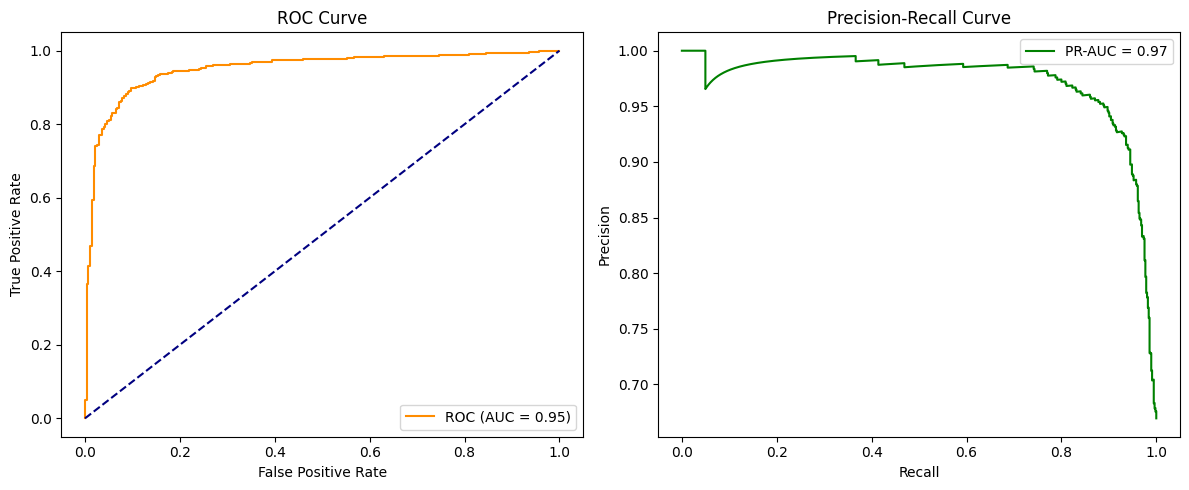

In [6]:
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve
from skimage.metrics import structural_similarity as ssim

def calculate_detailed_metrics(model_enc, model_gen, loader):
    model_enc.eval()
    model_gen.eval()
    
    mse_scores = []
    ssim_scores = []
    
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model_enc(x)
            recon = model_gen(mu)
            
            # 1. MSE Score (The anomaly signal)
            mse = torch.mean((x - recon)**2, dim=(1, 2, 3))
            mse_scores.extend(mse.cpu().numpy())
            
            # 2. SSIM Score (Structural Similarity - Optional but highly recommended)
            # We calculate this for a few samples to report average reconstruction quality
            for i in range(x.size(0)):
                orig_np = x[i].permute(1, 2, 0).cpu().numpy()
                recon_np = recon[i].permute(1, 2, 0).cpu().numpy()
                # Sentinel-2 data range is 1.0 after our normalization
                s = ssim(orig_np, recon_np, data_range=1.0, channel_axis=2)
                ssim_scores.append(s)
                
    return mse_scores, ssim_scores

# --- Execution ---
print("Calculating metrics for Val (Clean) and Test (Fire)...")
normal_mse, normal_ssim = calculate_detailed_metrics(enc, gen, val_loader)
anomaly_mse, anomaly_ssim = calculate_detailed_metrics(enc, gen, fire_loader)

# --- ROC and PR-AUC Logic ---
y_true = [0] * len(normal_mse) + [1] * len(anomaly_mse)
y_scores = normal_mse + anomaly_mse

# ROC AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# PR AUC (Precision-Recall) - Very important for anomaly detection
pr_auc = average_precision_score(y_true, y_scores)

# --- Find Optimal Threshold (Youden's J Statistic) ---
# J = Sensitivity + Specificity - 1
idx = np.argmax(tpr - fpr)
opt_threshold = thresholds[idx]

ssim_clean = np.mean(normal_ssim)
ssim_fire = np.mean(anomaly_ssim)
ssim_contrast = ssim_clean - ssim_fire

# --- Final Report ---
print(f"\n" + "="*30)
print(f"FINAL METRICS")
print(f"="*30)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
# print(f"Average SSIM (Clean): {np.mean(normal_ssim):.4f}")
print(f"Average SSIM (Clean): {ssim_clean:.4f}")
print(f"Average SSIM (Fire):  {ssim_fire:.4f}") 
print(f"SSIM (Clean - Fire):      {ssim_contrast:.4f}")
print(f"Optimal MSE Threshold: {opt_threshold:.6f}")
print(f"="*30)

# Visualization
plt.figure(figsize=(12, 5))

# Plot ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# Plot PR-Curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', label=f'PR-AUC = {pr_auc:.2f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.show()

## Testing & Anomaly Detection

--- Single Patch Evaluation ---
File: fire_brazil_183838.npy
Anomaly Score (MSE): 0.008851


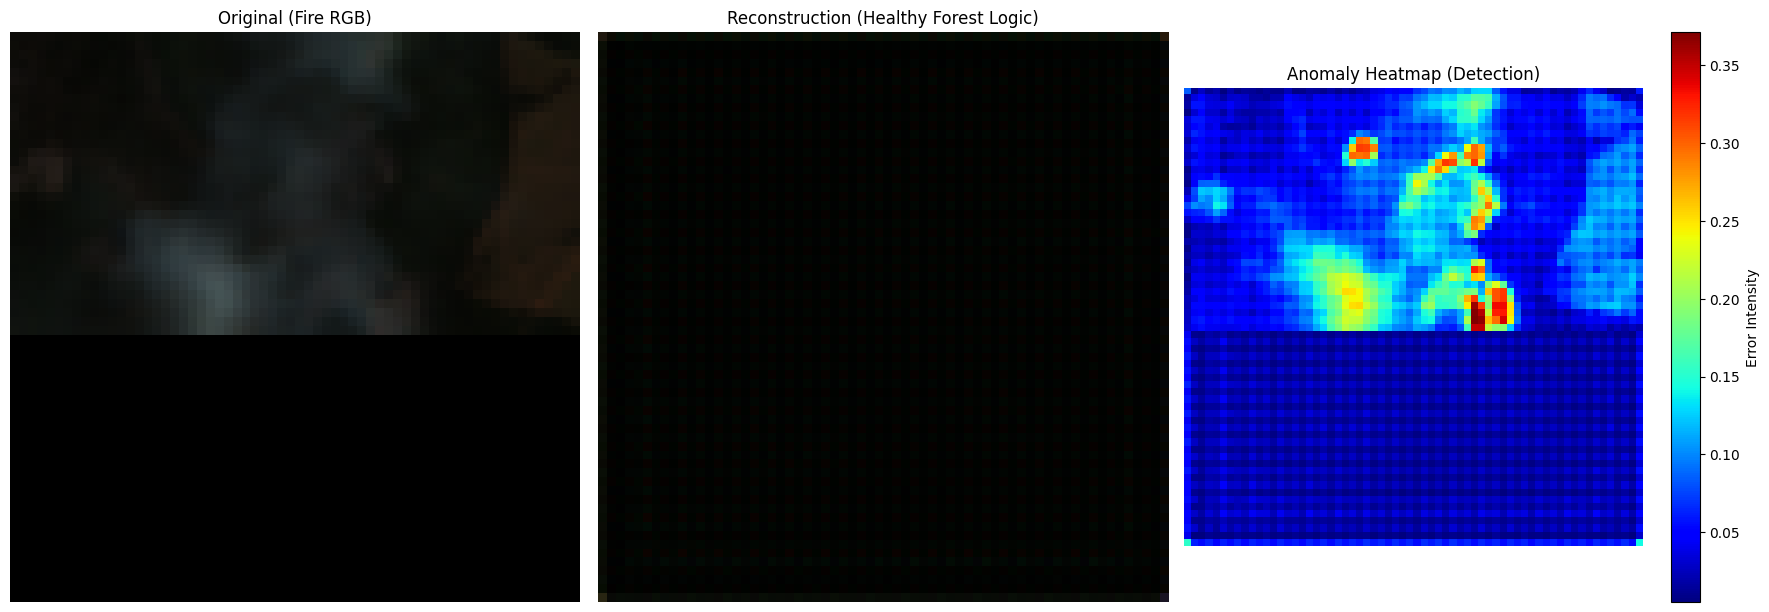

In [7]:
# Visualization
import glob
import torch.nn as nn

# Load a random Fire patch from the test set
fire_test_path = glob.glob('/kaggle/input/datasets/sefyou13/clean-forest-dataset-fire-forest-modis/dataset/test_fire/*.npy')[0]
fire_patch_raw = np.load(fire_test_path).astype(np.float32)

# Pre-process: Scale, Permute to (C, H, W), and add Batch dimension
fire_patch = torch.from_numpy(np.clip(fire_patch_raw/10000.0, 0, 1)).permute(2,0,1).unsqueeze(0).to(device)

# Model Inference
enc.eval()
gen.eval()
with torch.no_grad():
    mu, _ = enc(fire_patch)
    recon = gen(mu)
    
# Calculate Metrics
mse_score = nn.MSELoss()(recon, fire_patch)
# Residual map (Absolute difference)
diff = torch.abs(fire_patch - recon)

print(f"--- Single Patch Evaluation ---")
print(f"File: {os.path.basename(fire_test_path)}")
print(f"Anomaly Score (MSE): {mse_score.item():.6f}")

# 4. Professional 3-way Visualization
plt.figure(figsize=(18, 6))

# Subplot 1: Original RGB
plt.subplot(1, 3, 1)
plt.imshow(fire_patch[0, :3].cpu().permute(1, 2, 0))
plt.title("Original (Fire RGB)")
plt.axis('off')

# Subplot 2: VAE-WGAN Reconstruction
# The model tries to reconstruct this as a 'Healthy' forest
plt.subplot(1, 3, 2)
plt.imshow(recon[0, :3].cpu().permute(1, 2, 0))
plt.title("Reconstruction (Healthy Forest Logic)")
plt.axis('off')

# Subplot 3: Anomaly Heatmap (Residual)
# This highlights exactly where the fire/smoke differs from a normal forest

plt.subplot(1, 3, 3)
anomaly_map = diff[0].mean(dim=0).cpu() # Average error across all 4 bands
plt.imshow(anomaly_map, cmap='jet')
plt.title("Anomaly Heatmap (Detection)")
plt.colorbar(label='Error Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()